In [262]:
import pandas as pd
titanic_train = pd.read_csv("train.csv")
titanic_test = pd.read_csv("test.csv")
titanic = pd.concat([titanic_train,titanic_test])

In [263]:
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [264]:
titanic.drop(columns=['PassengerId','Name','Cabin'],inplace=True)

In [265]:
titanic.dropna(inplace=True)

In [266]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    float64
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Ticket    712 non-null    object 
 7   Fare      712 non-null    float64
 8   Embarked  712 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 55.6+ KB


In [267]:
titanic_tickets = []
for ticket in titanic['Ticket']:
    if ticket.split()[-1] != 'LINE':
        titanic_tickets.append(int(ticket.split()[-1]))
    else:
        titanic_tickets.append(0)
titanic['Ticket'] = titanic_tickets

In [268]:
titanic = pd.get_dummies(titanic,dtype=int)

In [269]:
titanic.corr()['Survived'].abs().sort_values(ascending=False)[1:]

Sex_male      0.536762
Sex_female    0.536762
Pclass        0.356462
Fare          0.266100
Embarked_C    0.195673
Embarked_S    0.159015
Ticket        0.103872
Parch         0.095265
Age           0.082446
Embarked_Q    0.048966
SibSp         0.015523
Name: Survived, dtype: float64

In [270]:
titanic.head()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3,22.0,1,0,21171,7.2500,0,1,0,0,1
1,1.0,1,38.0,1,0,17599,71.2833,1,0,1,0,0
2,1.0,3,26.0,0,0,3101282,7.9250,1,0,0,0,1
3,1.0,1,35.0,1,0,113803,53.1000,1,0,0,0,1
4,0.0,3,35.0,0,0,373450,8.0500,0,1,0,0,1


In [271]:
titanic.shape

(712, 12)

In [272]:
X = titanic.drop(['Survived'],axis=1)
y = titanic['Survived'].to_frame()

In [273]:
from sklearn.preprocessing import StandardScaler
escalador = StandardScaler()
X = escalador.fit_transform(X)

In [274]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#Max_depth permite limitar el número de niveles que tiene el árbol.
tree_clf = DecisionTreeClassifier(max_depth=3)
#criterion es lo que va a tratar de minimizar. Por defecto gini (homogeneidad)
tree_clf = DecisionTreeClassifier(criterion='entropy')
#min_samples_split numero mínimo de muestras para dividir un nodo.
tree_clf = DecisionTreeClassifier(min_samples_split=100)
#min_samples_leaf número mínimo de muestras para considerarlo una hoja.
tree_clf = DecisionTreeClassifier(min_samples_leaf=50)
#max_leaf_nodes es el número de hojas permitidas.
tree_clf = DecisionTreeClassifier(max_leaf_nodes=8)
#class_weight es para modificar el peso de las clases. 
tree_clf = DecisionTreeClassifier(class_weight={0:15,1:1})





#tree_clf = DecisionTreeClassifier(min_samples_leaf=20)
#tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 15, 1: 1})

In [289]:
y_pred = tree_clf.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7692307692307693

In [290]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.79      0.80        85
         1.0       0.70      0.74      0.72        58

    accuracy                           0.77       143
   macro avg       0.76      0.76      0.76       143
weighted avg       0.77      0.77      0.77       143



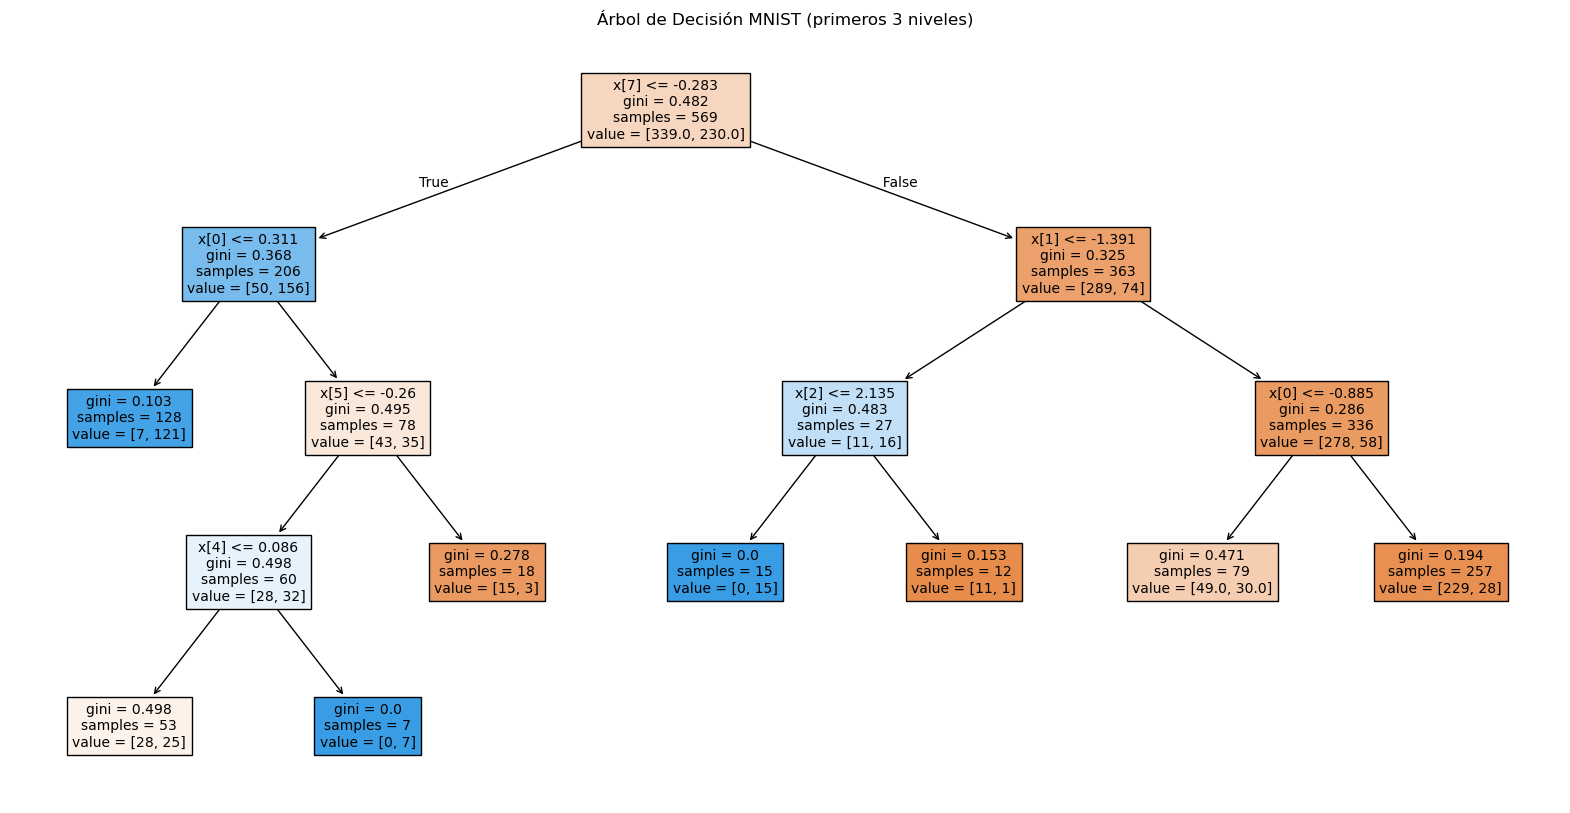

In [278]:
# Visualizar el árbol (solo primeros niveles por tamaño)
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
from sklearn.tree import plot_tree
plot_tree(tree_clf, 
          filled=True, 
          #feature_names=[f"pixel_{i}" for i in range(784)],
          #class_names=[str(i) for i in range(10)],
          #max_depth=3,  # Solo 2 niveles para que se vea
          fontsize=10)
plt.title("Árbol de Decisión MNIST (primeros 3 niveles)")
plt.show()

In [279]:
from sklearn.svm import SVC
clasificador = SVC(kernel='rbf',C=1)

In [280]:
clasificador.fit(X_train,y_train)
y_pred = clasificador.predict(X_test)
accuracy_score(y_test,y_pred)

c:\Users\Equipo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8251748251748252

In [281]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86        85
         1.0       0.82      0.72      0.77        58

    accuracy                           0.83       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.83      0.83      0.82       143

